# Configure Well Merge Module Params

This notebook uses the **whole well stitching approach** to merge phenotype and sbs data (for **tile-by-tile approach** use notebook 5a).
This notebook should be used as a test for ensuring correct merge parameters before merge processing.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for merge processing

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [1]:
CONFIG_FILE_PATH = "config/config.yml"

In [2]:
import warnings
from pathlib import Path
import yaml
import pandas as pd

from lib.shared.file_utils import get_filename
from lib.shared.configuration_utils import (
    plot_combined_tile_grid,
    plot_merge_example,
    preview_mask_transformations,
    CONFIG_FILE_HEADER,
)
from lib.merge.hash import hash_cell_locations, initial_alignment
from lib.merge.eval_merge import *

## <font color='red'>SET PARAMETERS</font>

### Determine merge plate-well combos
- `MERGE_COMBO_DF_FP`: Plate used for testing configuration

In [3]:
MERGE_COMBO_DF_FP = "config/merge_combo.tsv"

In [4]:
# load config file and determine root path
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)

SBS_COMBO_FP = Path(config["preprocess"]["sbs_combo_fp"])
sbs_wildcard_combos = pd.read_csv(SBS_COMBO_FP, sep="\t")
PHENOTYPE_COMBO_FP = Path(config["preprocess"]["phenotype_combo_fp"])
phenotype_wildcard_combos = pd.read_csv(PHENOTYPE_COMBO_FP, sep="\t")

# Generate plate-well combinations for merge
sbs_combos = set(zip(sbs_wildcard_combos["plate"], sbs_wildcard_combos["well"]))
phenotype_combos = set(
    zip(phenotype_wildcard_combos["plate"], phenotype_wildcard_combos["well"])
)
# Check if SBS and PHENOTYPE have the same plate-well combinations
if sbs_combos == phenotype_combos:
    merge_wildcard_combos = pd.DataFrame(list(sbs_combos), columns=["plate", "well"])
else:
    warnings.warn(
        "SBS and PHENOTYPE do not have matching plate-well combinations. Merging requires identical sets."
    )
    merge_wildcard_combos = pd.DataFrame(columns=["plate", "well"])

merge_wildcard_combos.to_csv(MERGE_COMBO_DF_FP, sep="\t", index=False)
merge_wildcard_combos

,plate,well
0,1,A3
1,1,B2


## <font color='red'>SET PARAMETERS</font>

### Parameters for testing merge module
- `TEST_PLATE`: Plate used for testing configuration 
- `TEST_WELL`: Well identifier used for testing configuration 

### Parameters for metadata extraction
- `SBS_METADATA_CYCLE`: Cycle number for extracting SBS data positions
- `SBS_METADATA_CHANNEL`: Optional channel for SBS metadata. This is necessary in the case that multiple channel-based images were acquired, and therefore, multiple channel-based metadata files exist.
- `PH_METADATA_CHANNEL`: Optional channel for phenotype metadata. This is necessary in the case that multiple channel-based images were acquired, and therefore, multiple channel-based metadata files exist.

In [5]:
TEST_PLATE = 1
TEST_WELL = "B2"

SBS_METADATA_CYCLE = 1
SBS_METADATA_CHANNEL = None
PH_METADATA_CHANNEL = None

In [6]:
ROOT_FP = Path(config["all"]["root_fp"])

# load phenotype and SBS metadata dfs
ph_filename_params = {"plate": TEST_PLATE, "well": TEST_WELL}
if PH_METADATA_CHANNEL is not None:
    ph_filename_params["channel"] = PH_METADATA_CHANNEL

ph_test_metadata_fp = (
    ROOT_FP
    / "preprocess"
    / "metadata"
    / "phenotype"
    / get_filename(ph_filename_params, "combined_metadata", "parquet")
)
ph_test_metadata = pd.read_parquet(ph_test_metadata_fp)

sbs_filename_params = {"plate": TEST_PLATE, "well": TEST_WELL}
if SBS_METADATA_CHANNEL is not None:
    sbs_filename_params["channel"] = SBS_METADATA_CHANNEL

sbs_test_metadata_fp = (
    ROOT_FP
    / "preprocess"
    / "metadata"
    / "sbs"
    / get_filename(sbs_filename_params, "combined_metadata", "parquet")
)
sbs_test_metadata = pd.read_parquet(sbs_test_metadata_fp)
sbs_test_metadata = sbs_test_metadata[sbs_test_metadata["cycle"] == SBS_METADATA_CYCLE]

In [7]:
# # Create plot with combined tile view
# combined_tile_grid = plot_combined_tile_grid(ph_test_metadata, sbs_test_metadata)
# combined_tile_grid.show()

## <font color='red'>SET PARAMETERS</font>
### Parameters for image stitching

`MASK_TYPE`: Type of object to segment.
- `"nuclei"` uses segmented nuclei masks.
- `"cells"` uses segmented cell masks.

`NUM_TILES`: Number of tiles to display. Higher numbers may increase processing time but allow a larger view of the well.

### Parameters for image orientation
Each microscope handles coordinates differently relative to the objective and image orientation. Adjust the following aprameters until you obtain a well image that looks right.

`FLIPUD`: Flip images upside-down (vertical flip). Defaults `False`.

`FLIPLR`: Flip images left-to-right (horizontal flip). Defaults `False`.

`ROT90_K`: Number of 90° rotations to apply to the image. For example, ROT90_K = 1 rotates the image 90° clockwise, ROT90_K = 2 rotates 180°, and so on.

In [7]:
MASK_TYPE = "nuclei"
NUM_TILES_PHENO = 12
NUM_TILES_SBS = 15
FLIPUD = False
FLIPLR = True
ROT90 = 0

In [9]:
# print("Testing phenotype data:")
# ph_params = preview_mask_transformations(
#     ph_test_metadata,
#     ROOT_FP,
#     "phenotype",
#     mask_type=MASK_TYPE,
#     num_tiles=NUM_TILES_PHENO,
#     flipud=FLIPUD,
#     fliplr=FLIPLR,
#     rot90=ROT90
# )


In [10]:

# print("\nTesting SBS data with same transformation:")
# sbs_params = preview_mask_transformations(
#     sbs_test_metadata,
#     ROOT_FP, 
#     "sbs",
#     mask_type=MASK_TYPE,
#     num_tiles=NUM_TILES_SBS,
#     flipud=FLIPUD,
#     fliplr=FLIPLR,
#     rot90=ROT90
# )


In [ ]:
# For SBS
if 'pixel_size_x' in sbs_test_metadata.columns:
    SBS_PIXEL_SIZE = sbs_test_metadata['pixel_size_x'].iloc[0]
    print(f"SBS pixel size: {SBS_PIXEL_SIZE:.6f} μm/pixel")
else:
    print("No pixel_size_x found in SBS metadata.")
    # Check what columns are available
    print(f"SBS columns: {list(sbs_test_metadata.columns)}")

# For Phenotype  
if 'pixel_size_x' in ph_test_metadata.columns:
    PHENOTYPE_PIXEL_SIZE = ph_test_metadata['pixel_size_x'].iloc[0]
    print(f"Phenotype pixel size: {PHENOTYPE_PIXEL_SIZE:.6f} μm/pixel")
else:
    print("No pixel_size_x found in phenotype metadata.")
    # Check what columns are available
    print(f"\nPhenotype columns: {list(ph_test_metadata.columns)}")


Phenotype columns: ['x_pos', 'y_pos', 'z_pos', 'pfs_offset', 'plate', 'well', 'tile', 'filename', 'channels', 'pixel_size_x', 'pixel_size_y']
SBS columns: ['x_pos', 'y_pos', 'z_pos', 'pfs_offset', 'plate', 'well', 'tile', 'cycle', 'filename', 'channels', 'pixel_size_x', 'pixel_size_y']
SBS pixel size: 1.300000 μm/pixel
Phenotype pixel size: 0.162500 μm/pixel


In [9]:
SBS_PIXEL_SIZE = None
PHENOTYPE_PIXEL_SIZE = None
OVERLAP_FRACTION = 0.05

<font color='red'>SET DEDUPLICATION PARAMETERS</font>

`SBS_DEDUP_PRIOR` & `PHENO_DEDUP_PRIOR`: Control how duplicate cell mappings are resolved through two sequential steps. Each parameter is a dictionary where:

**Keys**: Column names to sort by (e.g., distance, mapped_single_gene, fov_distance_0).

**Values**: Sort direction (True = ascending, False = descending).

**Order** matters: First column has highest priority, subsequent columns break ties.


**Step 1**: For each phenotype cell with multiple SBS matches, keeps the best SBS match
**Step 2**: For each remaining SBS cell with multiple phenotype matches, keeps the best phenotype match

**Example strategies:**
- `{"distance": True, "mapped_single_gene": False}`: Prioritize spatial accuracy first, then gene mapping quality
- `{"mapped_single_gene": False, "distance": True}`: Prioritize single-gene assignments first, then spatial proximity
- `{"distance": True, "fov_distance_0": True}`: Prefer close matches near field-of-view center

In [10]:
SBS_DEDUP_PRIOR = {"distance": True, "mapped_single_gene": False}
PHENO_DEDUP_PRIOR = {"distance": True}

## <font color='red'>SET PARAMETERS</font>

- `DET_RANGE`: Enforces valid magnification ratios between phenotype and genotype images. It needs to be adjusted based on:
    - Objective magnifications used (e.g., 20X vs 10X)
    - Camera binning settings (e.g., 2x2 binning vs unbinned)
    - To calculate for your setup:
        1. Determine total magnification difference (objectives × binning)
        2. Use (min/difference², max/difference²) where min/max are typically 0.9-1.15
    - You can narrow or expand the suggested `DET_RANGE` based on how closely or widely you want to ensure matches
- `SCORE` This parameter is the score of the transformation, typically 0.1
- `THRESHOLD`: Determines the maximum euclidean distance between a phenotype point and its matched SBS point for them to be considered a valid match

In [11]:
SCORE = 0.04
THRESHOLD = 12

**Eval Options:**
- `STITCHED_IMAGE`: Determines whether a stitched image will be produced for qc in addition to the stitched nuclei masks.

In [12]:
STITCHED_IMAGE = False

## Add merge parameters to config file

In [16]:
import yaml
from pathlib import Path

def convert_tuples_to_lists(obj):
    """Recursively convert all tuples in a data structure to lists."""
    if isinstance(obj, tuple):
        return [convert_tuples_to_lists(i) for i in obj]
    elif isinstance(obj, list):
        return [convert_tuples_to_lists(i) for i in obj]
    elif isinstance(obj, dict):
        return {k: convert_tuples_to_lists(v) for k, v in obj.items()}
    else:
        return obj

# Build the merge config section (well approach only)
config["merge"] = {
    "approach": "stitch",
    "merge_combo_fp": MERGE_COMBO_DF_FP,
    "sbs_metadata_cycle": SBS_METADATA_CYCLE,
    "score": SCORE,
    "stitched_image": STITCHED_IMAGE,
    "threshold": THRESHOLD,
    "flipud": FLIPUD,
    "fliplr": FLIPLR,
    "rot90": ROT90,
    "sbs_pixel_size": SBS_PIXEL_SIZE,
    "phenotype_pixel_size": PHENOTYPE_PIXEL_SIZE,
    "overlap_fraction": OVERLAP_FRACTION,
    "sbs_dedup_prior": SBS_DEDUP_PRIOR,
    "pheno_dedup_prior": PHENO_DEDUP_PRIOR,
}

# Convert tuples to lists before dumping
safe_config = convert_tuples_to_lists(config)

# Write the config safely
with open(CONFIG_FILE_PATH, "w") as config_file:
    config_file.write(CONFIG_FILE_HEADER)
    yaml.dump(safe_config, config_file, default_flow_style=False)

## <font color='red'>MERGE EVAL</font>

### Test distance thresholds
Examine merge fidelity given the chosen `THRESHOLD` value. This is the maximum euclidean distance between a phenotype point and its matched SBS point for them to be considered a valid match.

In [22]:
# Set new threshold if desired
THRESHOLD = 20
TEST_SITE = 102

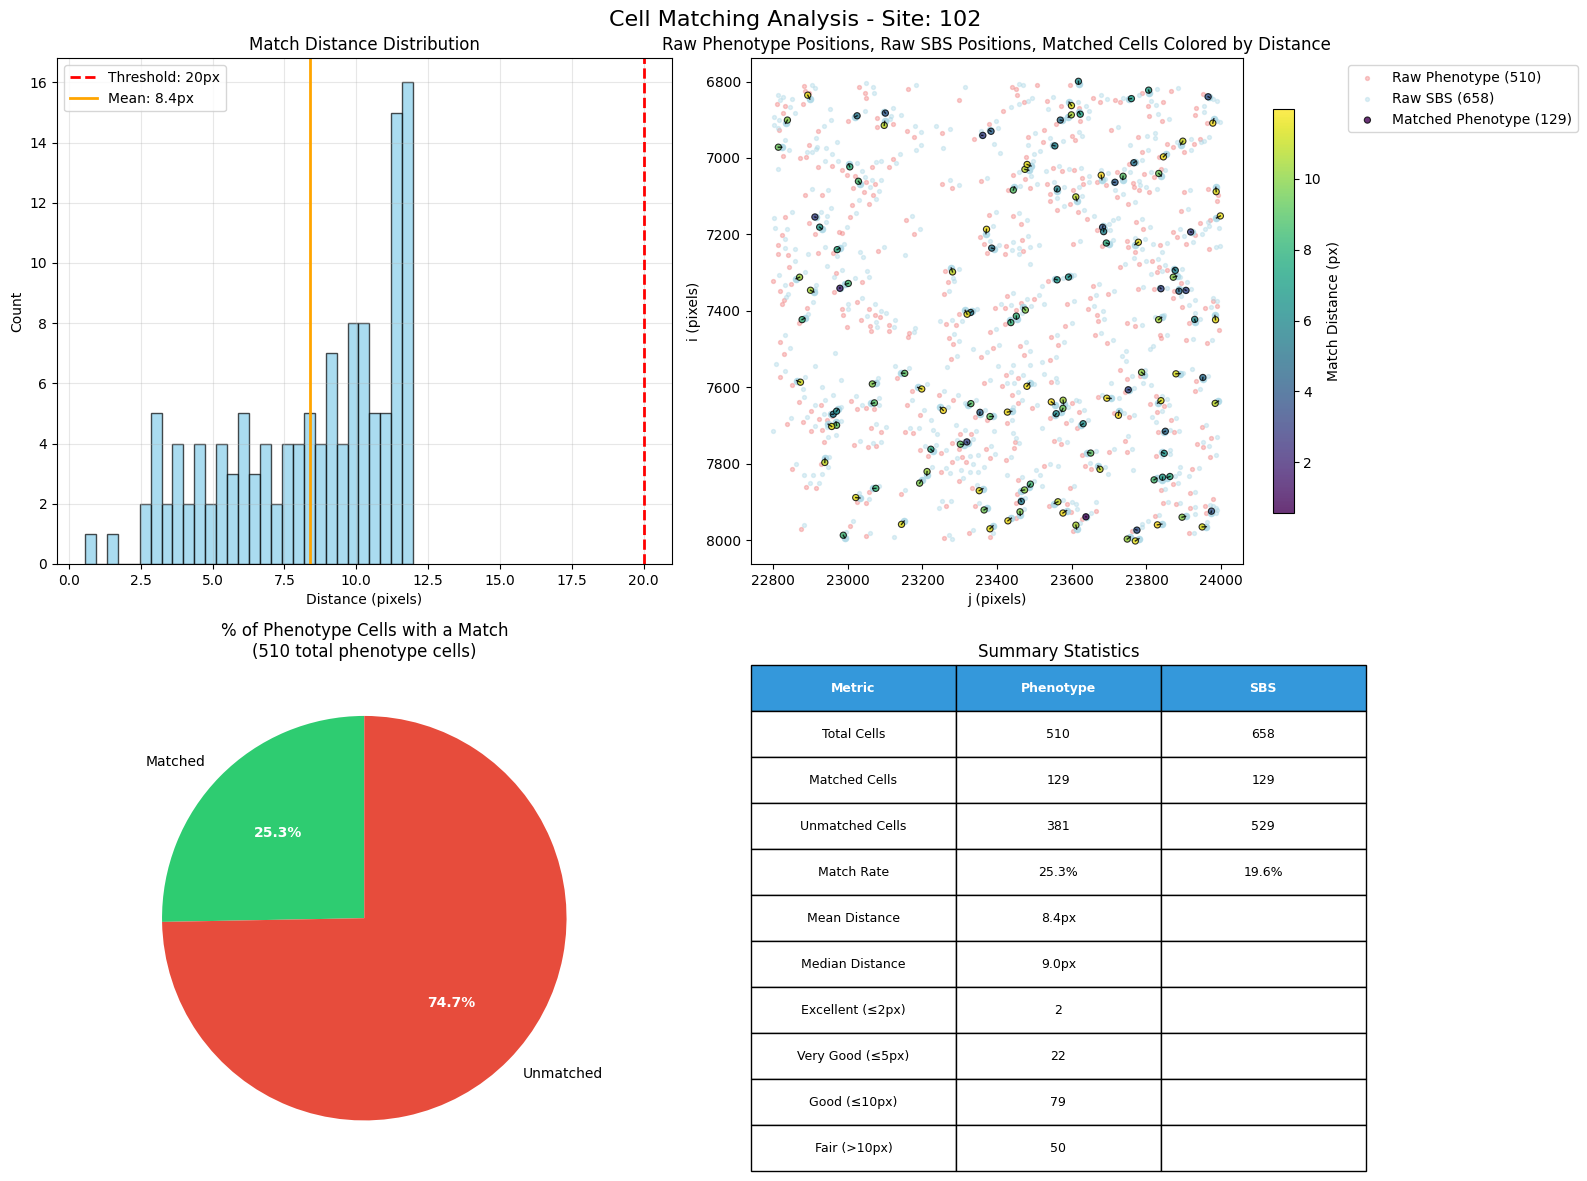

In [23]:
summary_stats = display_matched_and_unmatched_cells_for_site(
    ROOT_FP, TEST_PLATE, TEST_WELL,
    selected_site=TEST_SITE,    
    distance_threshold=THRESHOLD,
    verbose=False
)

## Add updated merge parameters to config file before re-run